In [1]:
import pandas as pd
import numpy as np
from cdc_ml.config import POLLS_PROCESSED,CUSTOMER_CLASS_PROCESSED
import xgboost as xgb
from cdc_ml.features.build_features import assign_class_type
from sklearn.model_selection import StratifiedGroupKFold
import seaborn as sns

from sklearn.metrics import brier_score_loss, average_precision_score
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import PercentFormatter
from cdc_ml.features.build_features import get_whale_users
from cdc_ml.plots import platt_recal
from sklearn.ensemble import RandomForestClassifier
from cdc_ml.modeling.train import train,StratifiedUsernameKFold

2026-06-04 16:14:40.317 | INFO     | cdc_ml.config:<module>:12 - PROJ_ROOT path is: C:\Users\zhiju\Desktop\cdc_ml


In [2]:
df = pd.read_parquet(POLLS_PROCESSED)
df_class = pd.read_parquet(CUSTOMER_CLASS_PROCESSED)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32492 entries, 0 to 32491
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype                         
---  ------             --------------  -----                         
 0   id                 32492 non-null  int64                         
 1   username           32492 non-null  str                           
 2   cycle_start        32492 non-null  datetime64[us, Asia/Singapore]
 3   cycle_end          32492 non-null  datetime64[us, Asia/Singapore]
 4   polling_at         32492 non-null  datetime64[us, Asia/Singapore]
 5   has_booking        32492 non-null  bool                          
 6   cycle_start_month  32492 non-null  int32                         
 7   cycle_start_day    32492 non-null  int32                         
 8   cycle_start_dow    32492 non-null  int32                         
 9   cycle_start_hour   32492 non-null  int32                         
 10  polling_month      32492 non-null  int32     

In [4]:
print(get_whale_users())

(Index(['anaya', 'anmol', 'flower', 'jy', 'kim', 'matt', 'mya', 'ryan'], dtype='str', name='username'), Index(['anmol', 'flower', 'joy', 'jun', 'jy', 'kim', 'mya', 'poopie'], dtype='str', name='username'))


In [5]:
df_train,df_test = StratifiedUsernameKFold(df)

Train share -> 0.7963190939308138
Test share -> 0.20368090606918626
Baseline positive rate -> 0.012187615413024745
Train positive rate -> 0.012483574244415242
Test positive rate -> 0.011030522816560894


In [6]:
df_train.groupby(["username"])["has_booking"].mean().sort_values(ascending=False)

username
anmol      0.041136
poopie     0.040897
joy        0.028605
ranjith    0.027778
jun        0.027611
carol      0.020833
ajithak    0.020000
pakning    0.019868
aswath     0.018100
bryan      0.017045
phuc       0.014354
mya        0.014024
isyaf      0.013889
tomato     0.013048
np         0.011765
faith      0.011414
sara       0.011299
lucinda    0.010204
srpr       0.009333
flower     0.006623
kim        0.005765
ryan       0.004067
anaya      0.004051
fir        0.003846
d          0.003788
natar      0.003623
gohguan    0.002837
matt       0.002543
bw         0.002079
Name: has_booking, dtype: float64

In [7]:
df_test.groupby(["username"])["has_booking"].mean().sort_values(ascending=False)

username
bhara      0.020833
max        0.020833
nur        0.018519
jy         0.015665
apple      0.011480
addity     0.010638
brendon    0.007663
ali        0.003871
Name: has_booking, dtype: float64

In [8]:
#seed = np.random.randint(0,100)
seed = 42
# if the features below is not removed , the model will overfit 
oof_xgb,oof_add=train(df_train,["polling_hour","polling_dow"],seed=seed)

fold 0: train n= 20681 val n=  5193   train_pos=0.013  val_pos=0.011
  marg_dow  brier=0.0105  pr=0.0128
  marg_hour brier=0.0104  pr=0.0212
  add       brier=0.0104  pr=0.0247
  joint     brier=0.0105  pr=0.0253
  rf        brier=0.0104  pr=0.0257
  xgb (val) brier=0.0104  pr=0.0241
  xgb (tr)  brier=0.0126  pr=0.0352

fold 1: train n= 20390 val n=  5484   train_pos=0.014  val_pos=0.007
  marg_dow  brier=0.0071  pr=0.0088
  marg_hour brier=0.0072  pr=0.0093
  add       brier=0.0072  pr=0.0114
  joint     brier=0.0073  pr=0.0102
  rf        brier=0.0073  pr=0.0110
  xgb (val) brier=0.0072  pr=0.0106
  xgb (tr)  brier=0.0135  pr=0.0390

fold 2: train n= 20955 val n=  4919   train_pos=0.011  val_pos=0.021
  marg_dow  brier=0.0204  pr=0.0256
  marg_hour brier=0.0202  pr=0.0390
  add       brier=0.0201  pr=0.0514
  joint     brier=0.0203  pr=0.0380
  rf        brier=0.0202  pr=0.0438
  xgb (val) brier=0.0201  pr=0.0502
  xgb (tr)  brier=0.0103  pr=0.0270

fold 3: train n= 20706 val n=  516

In [9]:
"""Calibration reliability diagrams segmented by polling-volume whales.

Drop into your viz/plotting module. Main entry point is
`plot_calibration_by_volume`, which takes pooled OOF predictions and plots
whale vs non-whale reliability curves with Wilson CIs plus prediction
histograms underneath.

Design choices baked in:
  * Segment on EXPOSURE (n_polls / is_whale), never on positive count — the
    slice must not be conditioned on the label.
  * Quantile (equal-count) bins, not equal-width, so no bin is mostly empty
    at the ~1.3% base rate. Edges are deduped, which also handles the
    discrete-prediction case (additive LUT emits one value per dow/hour cell).
  * Wilson score intervals for observed frequency — robust at low counts /
    extreme p, unlike the normal approximation.
  * Prediction histogram (log y) under the reliability axes so sparsity in the
    low-volume segment is visible rather than hidden.

Read points BELOW the diagonal as overprediction (observed < predicted) — the
non-whale failure mode you diagnosed.
"""

def wilson_interval(k, n, z=1.96):
    """95% Wilson score interval for a binomial proportion.

    Returns (p_hat, lower, upper). p_hat is the raw observed frequency (the
    plotted point); the interval is the Wilson score interval, which stays
    sensible when k is tiny or n is small.
    """
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    p = np.divide(k, n, out=np.zeros_like(k, dtype=float), where=n > 0)
    denom = 1.0 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = (z / denom) * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    lower = np.clip(center - half, 0.0, 1.0)
    upper = np.clip(center + half, 0.0, 1.0)
    return p, lower, upper


def _quantile_bin_index(p_pred, n_bins):
    """Assign each prediction to a quantile bin. Dedups edges, so the effective
    number of bins may be < n_bins when predictions are discrete (LUT) or
    heavily point-massed. Returns (edges, idx, n_effective)."""
    edges = np.quantile(p_pred, np.linspace(0.0, 1.0, n_bins + 1))
    edges = np.unique(edges)
    if len(edges) < 2:  # all predictions identical
        return edges, np.zeros(len(p_pred), dtype=int), 1
    idx = np.clip(np.digitize(p_pred, edges[1:-1], right=False), 0, len(edges) - 2)
    return edges, idx, len(edges) - 1


def reliability_table(p_pred, y_true, n_bins=10):
    """Per-bin mean predicted prob, observed freq, Wilson CI, and count."""
    p_pred = np.asarray(p_pred, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    _, idx, n_eff = _quantile_bin_index(p_pred, n_bins)

    x, k_arr, n_arr = [], [], []
    for b in range(n_eff):
        mask = idx == b
        n = int(mask.sum())
        if n == 0:
            continue
        x.append(p_pred[mask].mean())
        k_arr.append(y_true[mask].sum())
        n_arr.append(n)

    x = np.array(x)
    k_arr = np.array(k_arr)
    n_arr = np.array(n_arr)
    obs, lo, hi = wilson_interval(k_arr, n_arr)
    return {"x": x, "obs": obs, "lo": lo, "hi": hi, "n": n_arr, "k": k_arr}


def plot_calibration_by_volume(
    p_pred,
    y_true,
    is_whale,
    *,
    n_bins=10,
    title="Calibration by polling volume (pooled OOF)",
    ax_range=None,
):
    """Reliability diagram for whale vs non-whale segments.

    Parameters
    ----------
    p_pred : array of predicted P(has_booking) per polling row (pooled OOF).
    y_true : array of 0/1 has_booking labels, same length.
    is_whale : bool array, True for high-n_polls users. Use the SAME whale
        definition as your baseline sweep so the graph matches your weighting.
    n_bins : requested quantile bins (effective count may be lower).
    """
    p_pred = np.asarray(p_pred, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    is_whale = np.asarray(is_whale, dtype=bool)

    segments = {
        "whale (high n_polls)": (is_whale, "#2563eb"),
        "non-whale": (~is_whale, "#dc2626"),
    }

    if ax_range is None:
        hi_x = float(np.quantile(p_pred, 0.999))
        ax_range = (0.0, max(hi_x, float(y_true.mean()) * 3.0))

    fig = plt.figure(figsize=(20,10))
    gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.07)
    ax = fig.add_subplot(gs[0])
    axh = fig.add_subplot(gs[1], sharex=ax)

    # perfect-calibration reference
    ax.plot(ax_range, ax_range, ls="--", lw=1.0, color="#6b7280", label="perfect", zorder=1)

    for name, (mask, color) in segments.items():
        if mask.sum() == 0:
            continue
        t = reliability_table(p_pred[mask], y_true[mask], n_bins=n_bins)
        yerr = np.vstack(
            [np.clip(t["obs"] - t["lo"], 0, None), np.clip(t["hi"] - t["obs"], 0, None)]
        )
        ax.errorbar(
            t["x"],
            t["obs"],
            yerr=yerr,
            marker="o",
            ms=4.5,
            lw=1.6,
            capsize=2.5,
            color=color,
            zorder=3,
            label=f"{name}  (base={y_true[mask].mean():.2%}, " f"N={mask.sum():,})",
        )
        axh.hist(p_pred[mask], bins=40, range=ax_range, alpha=0.5, color=color, label=name)

    ax.set_xlim(*ax_range)
    ax.set_ylim(0, ax_range[1])
    ax.set_ylabel("Observed frequency")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=9, frameon=False)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.text(
        0.97,
        0.04,
        "below diagonal = overprediction",
        transform=ax.transAxes,
        ha="right",
        fontsize=8.5,
        color="#6b7280",
        style="italic",
    )
    plt.setp(ax.get_xticklabels(), visible=False)

    axh.set_yscale("log")
    axh.set_ylabel("rows")
    axh.set_xlabel("Predicted P(has_booking)")
    axh.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    axh.legend(loc="upper right", fontsize=8, frameon=False)

    fig.align_ylabels([ax, axh])


poll 90/168 cells (54% of polling) -> 90% of bookings


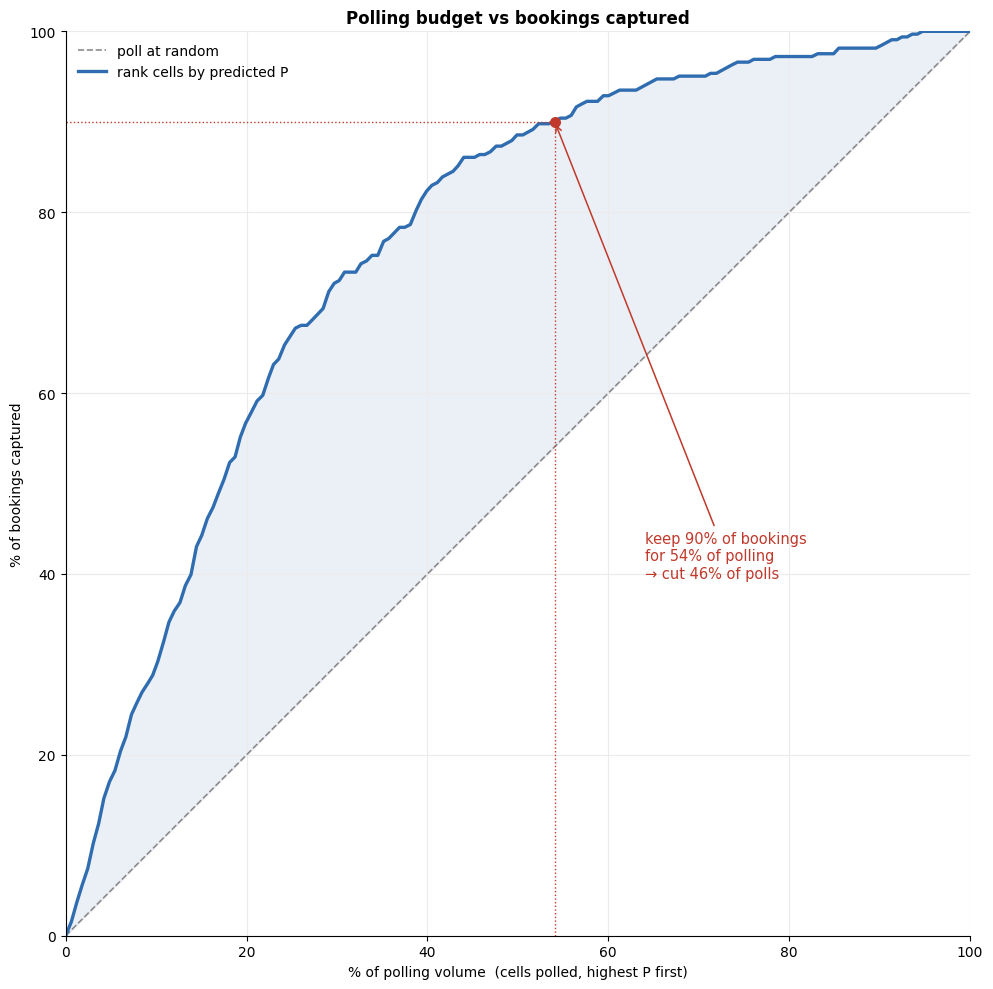

top 10% polling -> 30.3% bookings (lift 2.98x)
top 20% polling -> 57.9% bookings (lift 2.82x)
top 30% polling -> 72.4% bookings (lift 2.40x)
top 50% polling -> 88.5% bookings (lift 1.75x)
top 60% polling -> 92.9% bookings (lift 1.55x)


In [10]:
cell = (
    df_train.assign(oof=oof_add)                    # oof_xgb is already row-aligned to df_train
            .groupby(["polling_dow", "polling_hour"])
            .agg(pred=("oof", "mean"),              # cell's predicted P (mean over folds)
                 polls=("has_booking", "size"),     # volume = rows in the cell
                 bookings=("has_booking", "sum"))   # actual bookings in the cell
            .reset_index()
            .sort_values("pred", ascending=False)   # rank cells by P — and DON'T re-sort after
            .reset_index(drop=True)
)
cell["cum_polls"]    = cell["polls"].cumsum()                       # ONE global cumsum down the ranking
cell["cum_bookings"] = cell["bookings"].cumsum()
cell["pct_polls"]    = cell["cum_polls"]    / cell["polls"].sum()    # x-axis: % of polling
cell["pct_bookings"] = cell["cum_bookings"] / cell["bookings"].sum() # y-axis: % of bookings caught
cell["lift"]         = cell["pct_bookings"] / cell["pct_polls"]

target_recall = 0.90                                                # keep 90% of bookings
tau = cell.loc[cell.pct_bookings >= target_recall, "pred"].iloc[0]  # implied threshold
cell["poll"] = cell["pred"] >= tau                                  # True = poll, else skip
schedule = cell.loc[cell.poll, ["polling_dow", "polling_hour", "pred"]]

print(f"poll {cell.poll.sum()}/{len(cell)} cells "
      f"({cell.loc[cell.poll,'polls'].sum()/cell.polls.sum():.0%} of polling) "
      f"-> {cell.loc[cell.poll,'bookings'].sum()/cell.bookings.sum():.0%} of bookings")

x = np.insert(cell["pct_polls"].to_numpy()*100, 0, 0)   # prepend origin
y = np.insert(cell["pct_bookings"].to_numpy()*100, 0, 0)

fig, ax = plt.subplots(figsize=(20,10))
ax.plot([0,100],[0,100], "--", color="0.55", lw=1.2, label="poll at random")
ax.fill_between(x, x, y, color="#3b6fb0", alpha=0.10)
ax.plot(x, y, color="#2f6db0", lw=2.4, label="rank cells by predicted P")

op = cell[cell["pct_bookings"] >= 0.90].iloc[0]          # smallest budget keeping 90% of bookings
ox = op["pct_polls"]*100
ax.scatter([ox],[90], s=48, color="#c0392b", zorder=6)
ax.vlines(ox, 0, 90, color="#c0392b", ls=":", lw=1)
ax.hlines(90, 0, ox, color="#c0392b", ls=":", lw=1)
ax.annotate(f"keep 90% of bookings\nfor {ox:.0f}% of polling\n→ cut {100-ox:.0f}% of polls",
            xy=(ox,90), xytext=(ox+10, 42), fontsize=10.5, color="#c0392b", va="center",
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.1))

ax.set_xlim(0,100); ax.set_ylim(0,100); ax.set_aspect("equal")
ax.set_xlabel("% of polling volume  (cells polled, highest P first)")
ax.set_ylabel("% of bookings captured")
ax.set_title("Polling budget vs bookings captured", fontweight="bold")
ax.legend(loc="upper left", frameon=False)
ax.grid(True, color="0.92", lw=0.8)
for s in ["top","right"]: ax.spines[s].set_visible(False)
fig.tight_layout(); plt.show()

for k in (10, 20, 30, 50, 60):                               # numbers for your slide text
    r = cell[cell.pct_polls >= k/100].iloc[0]
    print(f"top {k:>2d}% polling -> {r.pct_bookings:5.1%} bookings (lift {r.lift:.2f}x)")